In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class FastDataset(Dataset):
    def __init__(self, path):
        self.data = torch.load(path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        d = self.data[idx]
        return d["seq"], d["rg"], d["dist"]

dataset = FastDataset("/content/drive/MyDrive/processed_dataset_6x6.pt")

loader = DataLoader(dataset, batch_size=8, shuffle=True)

print("Dataset size:", len(dataset))

Mounted at /content/drive
Dataset size: 800


In [ ]:
def compute_pairwise_6x6(dist, seq):
    """
    dist: (B, L, L, bins)
    seq:  (B, L) values in [0..5]

    returns:
        (B, 6, 6, bins)
    """
    B, L, _, bins = dist.shape

    out = torch.zeros(B, 6, 6, bins, device=dist.device)
    counts = torch.zeros(B, 6, 6, 1, device=dist.device)

    for a in range(6):
        for b in range(6):
            mask_i = (seq == a).unsqueeze(2)   # (B, L, 1)
            mask_j = (seq == b).unsqueeze(1)   # (B, 1, L)

            mask = mask_i & mask_j             # (B, L, L)

            mask = mask.unsqueeze(-1)          # (B, L, L, 1)

            pair_sum = (dist * mask).sum(dim=(1,2))   # (B, bins)
            pair_count = mask.sum(dim=(1,2))          # (B, 1)

            out[:, a, b] = pair_sum
            counts[:, a, b] = pair_count + 1e-8

    out = out / counts
    return out

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def compute_pairwise_6x6(dist, seq):
    B, L, _, bins = dist.shape

    out = torch.zeros(B, 6, 6, bins, device=dist.device)
    counts = torch.zeros(B, 6, 6, 1, device=dist.device)

    for a in range(6):
        for b in range(6):
            mask_i = (seq == a).unsqueeze(2)
            mask_j = (seq == b).unsqueeze(1)
            mask = (mask_i & mask_j).unsqueeze(-1)

            pair_sum = (dist * mask).sum(dim=(1,2))
            pair_count = mask.sum(dim=(1,2))

            out[:, a, b] = pair_sum
            counts[:, a, b] = pair_count + 1e-8

    return out / counts


# ----------------------------
# MODEL
# ----------------------------
class RgModel(nn.Module):
    def __init__(self, bins=32):
        super().__init__()

        self.d_model = 96

        # ---- SEQUENCE ----
        self.embedding = nn.Embedding(6, self.d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=4,
            dim_feedforward=192,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        self.rg_seq_head = nn.Sequential(
            nn.Linear(self.d_model, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

        # ---- DISTRIBUTION (REAL ONE NOW) ----
        self.dist_encoder = nn.Sequential(
            nn.Linear(6 * 6 * bins, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        self.rg_dist_head = nn.Linear(64, 1)

        # ---- FUSION ----
        self.fusion = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, seq, dist):
        # ----------------------------
        # SEQUENCE PATH
        # ----------------------------
        h = self.embedding(seq)
        h = self.transformer(h)

        h_mean = h.mean(dim=1)
        rg_seq = self.rg_seq_head(h_mean).squeeze(-1)

        # ----------------------------
        # DISTRIBUTION PATH
        # ----------------------------
        pairwise = compute_pairwise_6x6(dist, seq)   # (B, 6, 6, bins)
        pairwise = pairwise.view(pairwise.size(0), -1)

        dist_feat = self.dist_encoder(pairwise)
        rg_dist = self.rg_dist_head(dist_feat).squeeze(-1)

        # ----------------------------
        # FUSION
        # ----------------------------
        fused = torch.stack([rg_seq, rg_dist], dim=1)
        rg_final = self.fusion(fused).squeeze(-1)

        return rg_final, rg_seq, rg_dist

In [ ]:
from IPython.display import clear_output
import matplotlib.pyplot as plt

model = RgModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

def corr_loss(pred, target):
    pred = pred - pred.mean()
    target = target - target.mean()
    return - (pred * target).mean() / (pred.std() * target.std() + 1e-8)

epochs = 20
train_losses = []

for epoch in range(epochs):
    total_loss = 0
    all_preds = []

    model.train()

    for i, (x, y_rg, dist) in enumerate(loader):
        x = x.to(device)
        y_rg = y_rg.to(device)
        dist = dist.to(device)

        # ----------------------------
        # FORWARD
        # ----------------------------
        pred_rg, rg_seq, rg_dist = model(x, dist)

        # ----------------------------
        # LOSS
        # ----------------------------
        loss = (
            F.mse_loss(pred_rg, y_rg)
            + 0.3 * F.mse_loss(rg_seq, y_rg)
            + 0.3 * F.mse_loss(rg_dist, y_rg)
            + 0.2 * corr_loss(pred_rg, y_rg)
        )

        # ----------------------------
        # BACKPROP
        # ----------------------------
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        all_preds.append(pred_rg.detach().cpu())

        # ----------------------------
        # LIVE PLOT
        # ----------------------------
        if i % 10 == 0:
            clear_output(wait=True)

            avg_loss = total_loss / (i + 1)
            pred_std = torch.cat(all_preds).std().item()

            plt.figure(figsize=(8,5))
            plt.plot(train_losses + [avg_loss], marker='o')
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.title(f"Epoch {epoch+1}, Batch {i}")
            plt.grid()
            plt.show()

            print(f"Epoch {epoch+1}, Batch {i}")
            print(f"Loss: {avg_loss:.4f}")
            print(f"Pred std: {pred_std:.3f}")

    train_losses.append(total_loss / len(loader))

# ----------------------------
# SAVE
# ----------------------------
torch.save(model.state_dict(), "rg_model_with_dist.pt")

RuntimeError: The size of tensor a (6) must match the size of tensor b (150) at non-singleton dimension 2

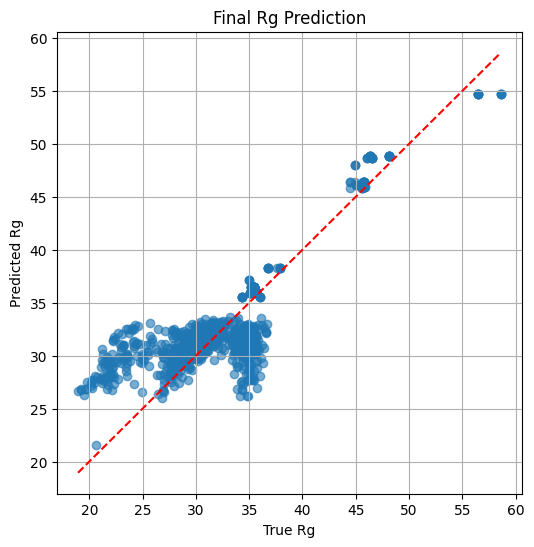

MAE: 2.734
RMSE: 3.607
Correlation: 0.836
Pred std: 5.414


In [ ]:
import torch
import matplotlib.pyplot as plt

model.eval()

all_true = []
all_pred = []

with torch.no_grad():
    for x, y_rg, _ in loader:
        x = x.to(device)
        y_rg = y_rg.to(device)

        pred_rg = model(x)  # ✅ FIXED

        all_true.append(y_rg.cpu())
        all_pred.append(pred_rg.cpu())

all_true = torch.cat(all_true)
all_pred = torch.cat(all_pred)

# ----------------------------
# PLOT
# ----------------------------
plt.figure(figsize=(6,6))
plt.scatter(all_true, all_pred, alpha=0.6)

minv = min(all_true.min(), all_pred.min())
maxv = max(all_true.max(), all_pred.max())

plt.plot([minv, maxv], [minv, maxv], 'r--')

plt.xlabel("True Rg")
plt.ylabel("Predicted Rg")
plt.title("Final Rg Prediction")

plt.grid()
plt.show()

# ----------------------------
# METRICS
# ----------------------------
mae = (all_true - all_pred).abs().mean().item()
rmse = torch.sqrt(((all_true - all_pred)**2).mean()).item()

corr = torch.corrcoef(torch.stack([all_true, all_pred]))[0,1].item()

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"Correlation: {corr:.3f}")
print(f"Pred std: {all_pred.std().item():.3f}")

In [ ]:
# save model
torch.save(model.state_dict(), "rg_model.pt")

In [ ]:
import torch
import torch.nn.functional as F

# ----------------------------
# LOAD MODEL
# ----------------------------
model = RgModel().to(device)
model.load_state_dict(torch.load("rg_model.pt"))

# ----------------------------
# RECREATE OPTIMIZER
# ----------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

# ----------------------------
# LOSS (same as before)
# ----------------------------
def corr_loss(pred, target):
    pred = pred - pred.mean()
    target = target - target.mean()
    return - (pred * target).mean() / (pred.std() * target.std() + 1e-8)

# ----------------------------
# CONTINUE TRAINING
# ----------------------------
more_epochs = 30  # change if you want longer

for epoch in range(more_epochs):
    total_loss = 0
    all_preds = []

    model.train()

    for x, y_rg, _ in loader:
        x = x.to(device)
        y_rg = y_rg.to(device)

        pred_rg = model(x)

        loss_mse = F.mse_loss(pred_rg, y_rg)
        loss_corr = corr_loss(pred_rg, y_rg)

        loss = loss_mse + 0.3 * loss_corr

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        all_preds.append(pred_rg.detach().cpu())

    all_preds = torch.cat(all_preds)

    print(f"[CONTINUE] Epoch {epoch+1}")
    print(f"Loss: {total_loss / len(loader):.4f}")
    print(f"Rg std: {all_preds.std().item():.3f}")
    print("-"*30)

# ----------------------------
# SAVE AGAIN
# ----------------------------
torch.save(model.state_dict(), "rg_model.pt")

[CONTINUE] Epoch 1
Loss: 13.0921
Rg std: 5.455
------------------------------
[CONTINUE] Epoch 2
Loss: 12.8650
Rg std: 5.438
------------------------------
[CONTINUE] Epoch 3
Loss: 12.9177
Rg std: 5.403
------------------------------
[CONTINUE] Epoch 4
Loss: 13.2811
Rg std: 5.458
------------------------------
[CONTINUE] Epoch 5
Loss: 12.9665
Rg std: 5.350
------------------------------
[CONTINUE] Epoch 6
Loss: 12.8157
Rg std: 5.471
------------------------------
[CONTINUE] Epoch 7
Loss: 12.7609
Rg std: 5.448
------------------------------


KeyboardInterrupt: 